# Dissertation plots

Figures are ordered as: classical codes, topological codes, MKMN codes, bivariate-bicycle codes, and asymmetric codes. Captions are printed in notebook output and are not embedded in the saved images; multi-panel images use panel letters only.


In [108]:
from pathlib import Path
from math import comb
import glob
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.special import ndtr

plt.rcParams.update({
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 16,
})

DISTANCES = (3, 5, 7, 9, 11)
SQRT_PI = np.sqrt(np.pi)
BLUE_GREEN_CMAP = plt.cm.viridis

def blue_green_colours(values, low=0.10, high=0.90):
    return dict(zip(values, BLUE_GREEN_CMAP(np.linspace(low, high, len(values)))))

def print_caption(text):
    print(f"Figure caption: {text}")

def gkp_physical_error_rate(sigmas, number_of_intervals=100):
    sigmas = np.asarray(sigmas, dtype=float)
    probability = np.zeros_like(sigmas)
    for m in range(number_of_intervals):
        lower = (2 * m + 0.5) * SQRT_PI / sigmas
        upper = (2 * m + 1.5) * SQRT_PI / sigmas
        probability += 2 * (ndtr(-lower) - ndtr(-upper))
    return probability

def load_curve(path, distance):
    path = Path(path)
    final_path = path.with_name(f'final_{path.name}')
    if final_path.exists():
        path = final_path
    with path.open(encoding='utf-8') as file:
        distance_data = json.load(file)[str(distance)]

    if isinstance(distance_data, dict) and isinstance(distance_data.get('sigma'), list):
        sigma = np.asarray(distance_data['sigma'], dtype=float)
        rate = np.asarray(distance_data['rate'], dtype=float)
        error = np.asarray(distance_data['error_bar'], dtype=float)
        physical = gkp_physical_error_rate(sigma)
    else:
        points = sorted(distance_data.values(), key=lambda point: point['sigma'])
        sigma = np.asarray([point['sigma'] for point in points], dtype=float)
        rate = np.asarray([point['rate'] for point in points], dtype=float)
        error = np.asarray([point['error_bar'] for point in points], dtype=float)
        physical = np.asarray([point.get('physical_error_probability', np.nan) for point in points], dtype=float)
        missing = ~np.isfinite(physical)
        physical[missing] = gkp_physical_error_rate(sigma[missing])

    order = np.argsort(sigma)
    return sigma[order], physical[order], rate[order], error[order]

def closest_connected_point(curves):
    """Return the sampled x value where all connected curves are closest."""
    sampled = []
    for physical, rate in curves:
        sampled.append({round(float(x), 12): float(y)
                        for x, y in zip(physical, rate) if x > 0 and y > 0})
    common_x = sorted(set.intersection(*(set(curve) for curve in sampled)))
    if not common_x:
        raise ValueError('Curves have no common positive sampled points')
    return min(common_x, key=lambda x: np.std(np.log([curve[x] for curve in sampled])))

def load_block_curve(path):
    path = Path(path)
    final_path = path.with_name(f'final_{path.name}')
    if final_path.exists():
        path = final_path
    with path.open(encoding='utf-8') as file:
        code_data = next(iter(json.load(file).values()))

    if isinstance(code_data.get('sigma'), list):
        sigma = np.asarray(code_data['sigma'], dtype=float)
        rate_key = 'block_rate' if 'block_rate' in code_data else 'rate'
        error_key = 'block_error_bar' if 'block_error_bar' in code_data else 'error_bar'
        rate = np.asarray(code_data[rate_key], dtype=float)
        error = np.asarray(code_data[error_key], dtype=float)
        physical = gkp_physical_error_rate(sigma)
    else:
        points = sorted(code_data.values(), key=lambda point: point['sigma'])
        sigma = np.asarray([point['sigma'] for point in points], dtype=float)
        rate_key = 'block_rate' if 'block_rate' in points[0] else 'rate'
        error_key = 'block_error_bar' if 'block_error_bar' in points[0] else 'error_bar'
        rate = np.asarray([point[rate_key] for point in points], dtype=float)
        error = np.asarray([point[error_key] for point in points], dtype=float)
        physical = np.asarray([point.get('physical_error_probability', np.nan) for point in points], dtype=float)
        missing = ~np.isfinite(physical)
        physical[missing] = gkp_physical_error_rate(sigma[missing])

    order = np.argsort(sigma)
    return sigma[order], physical[order], rate[order], error[order]

def prefer_existing(preferred, fallback):
    return preferred if Path(preferred).exists() else fallback


## Classical codes

Exact majority-vote logical error probabilities for distances 3, 5, 7, 9, and 11. The linear-scale plot is shown first, followed by the log-scale plot.


Figure caption: Logical bit-error probability of odd-distance classical repetition codes under independent bit flips, shown on a linear scale. The dashed line marks the majority-vote threshold p=0.5.


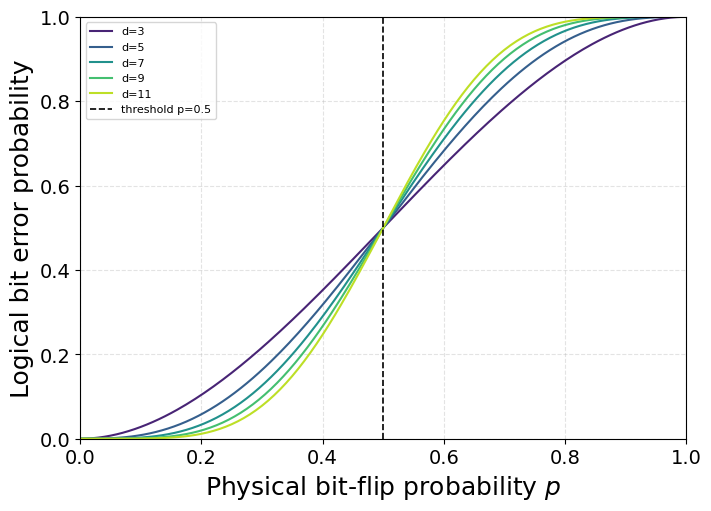

Figure caption: Logical bit-error probability of the same repetition codes on a logarithmic scale, emphasizing below-threshold suppression with increasing distance.


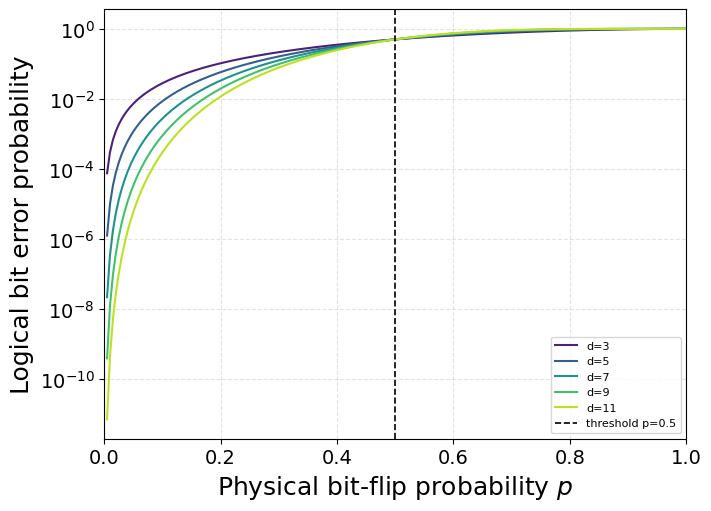

In [109]:
CLASSICAL_DISTANCES = (3, 5, 7, 9, 11)
classical_p = np.linspace(0.0, 1.0, 201)

def repetition_logical_error_rate(distance, physical_error_rate):
    p = np.asarray(physical_error_rate, dtype=float)
    return sum(
        comb(distance, weight) * p**weight * (1.0 - p)**(distance - weight)
        for weight in range(distance // 2 + 1, distance + 1)
    )

classical_rates = {distance: repetition_logical_error_rate(distance, classical_p)
                   for distance in CLASSICAL_DISTANCES}
classical_colors = blue_green_colours(CLASSICAL_DISTANCES)

print_caption('Logical bit-error probability of odd-distance classical repetition codes under independent bit flips, shown on a linear scale. The dashed line marks the majority-vote threshold p=0.5.')
fig, axis = plt.subplots(figsize=(7, 5), constrained_layout=True)
for distance, rate in classical_rates.items():
    axis.plot(classical_p, rate, color=classical_colors[distance], label=f'd={distance}')
axis.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='threshold p=0.5')
axis.set(xlabel=r'Physical bit-flip probability $p$', ylabel='Logical bit error probability',
         xlim=(0, 1), ylim=(0, 1))
axis.grid(True, linestyle='--', alpha=0.35)
axis.legend(fontsize=8)
fig.savefig('classical_repetition_linear.png', dpi=300, bbox_inches='tight')
plt.show()

print_caption('Logical bit-error probability of the same repetition codes on a logarithmic scale, emphasizing below-threshold suppression with increasing distance.')
fig, axis = plt.subplots(figsize=(7, 5), constrained_layout=True)
for distance, rate in classical_rates.items():
    visible = rate > 0
    axis.plot(classical_p[visible], rate[visible], color=classical_colors[distance], label=f'd={distance}')
axis.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='threshold p=0.5')
axis.set_yscale('log')
axis.set(xlabel=r'Physical bit-flip probability $p$', ylabel='Logical bit error probability', xlim=(0, 1))
axis.grid(True, which='both', linestyle='--', alpha=0.35)
axis.legend(fontsize=8)
fig.savefig('classical_repetition_log.png', dpi=300, bbox_inches='tight')
plt.show()


## Topological codes


## Below-threshold exponential suppression

These figures use the dedicated suppression datasets. Standard and soft-GKP decoding are shown in separate panels using the same distance colours.


Figure caption: Planar Surface code below-threshold suppression. a) Standard decoding. b) Soft-GKP decoding. Viridis colour denotes code distance; dotted lines mark the sampled convergence estimates.


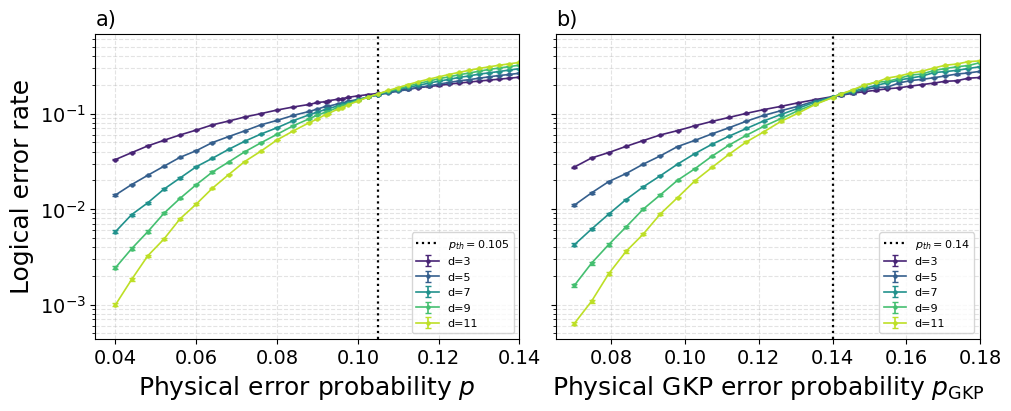

Figure caption: 2D Toric code below-threshold suppression. a) Standard decoding. b) Soft-GKP decoding. Viridis colour denotes code distance; dotted lines mark the sampled convergence estimates.


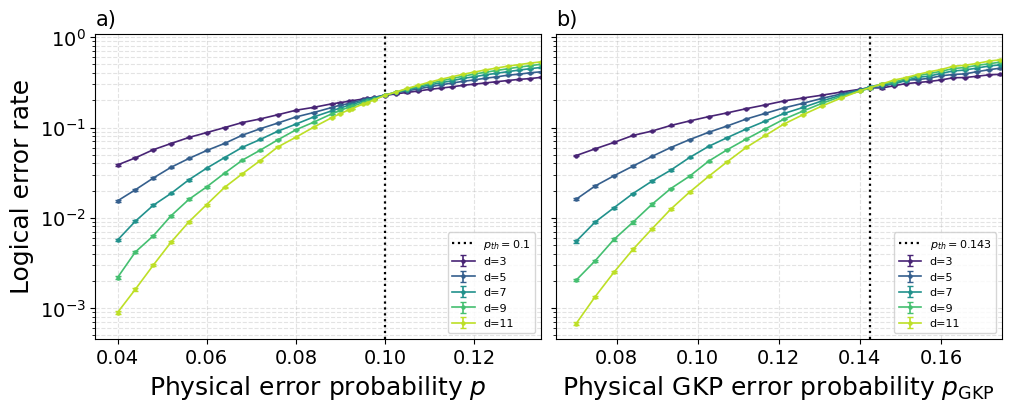

Figure caption: Triangular colour code below-threshold suppression. a) Standard decoding. b) Soft-GKP decoding. Viridis colour denotes code distance; dotted lines mark the sampled convergence estimates.


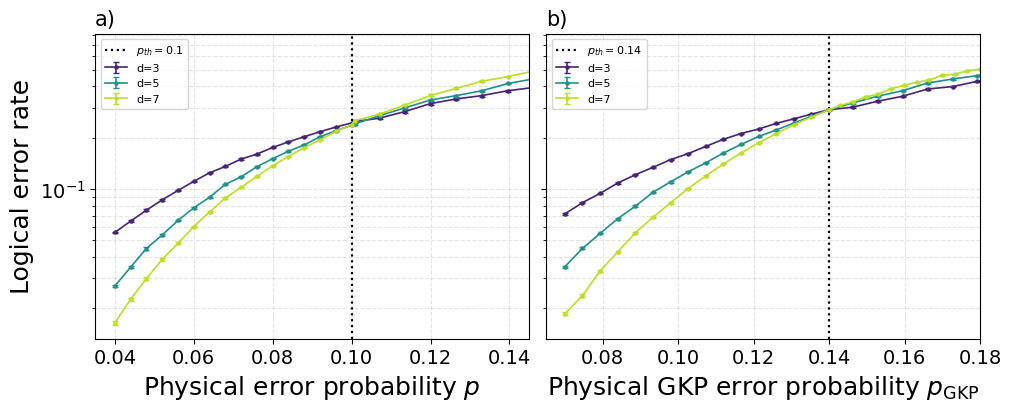

In [110]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def load_suppression_curve(filename):
    path = Path(filename)
    final_path = path.with_name(f'final_{path.name}')
    if final_path.exists():
        path = final_path
        
    with path.open(encoding='utf-8') as file:
        saved = next(iter(json.load(file).values()))
        
    if isinstance(saved.get('sigma'), list):
        sigma = np.asarray(saved['sigma'], dtype=float)
        rate = np.asarray(saved['block_rate'], dtype=float)
        error = np.asarray(saved['block_error_bar'], dtype=float)
        physical = gkp_physical_error_rate(sigma)
    else:
        # Extract points safely
        points = sorted((point for point in saved.values() if 'sigma' in point), key=lambda point: point['sigma'])
        sigma = np.asarray([point['sigma'] for point in points], dtype=float)
        
        # Look inside the first dictionary element of the list to find the correct key string
        first_point = points[0] if points else {}
        rate_name = 'block_rate' if 'block_rate' in first_point else 'rate'
        error_name = 'block_error_bar' if 'block_error_bar' in first_point else 'error_bar'
        
        rate = np.asarray([point[rate_name] for point in points], dtype=float)
        error = np.asarray([point[error_name] for point in points], dtype=float)
        physical = np.asarray([point.get('physical_error_probability', np.nan) for point in points], dtype=float)
        
        missing = ~np.isfinite(physical)
        physical[missing] = gkp_physical_error_rate(sigma[missing])
        
    order = np.argsort(physical)
    return physical[order], rate[order], error[order]

def merge_curve_ranges(suppression_file, threshold_file):
    suppression_x, suppression_rate, suppression_error = load_suppression_curve(suppression_file)
    threshold_x, threshold_rate, threshold_error = load_suppression_curve(threshold_file)
    
    # Store using rounded floats uniformly to prevent precision lookup failures
    merged = {round(float(x), 12): (float(y), float(dy)) for x, y, dy in zip(suppression_x, suppression_rate, suppression_error)}
    
    for x_val, y, dy in zip(threshold_x, threshold_rate, threshold_error):
        if x_val > suppression_x.max() + 1e-12:
            merged[round(float(x_val), 12)] = (float(y), float(dy))
            
    # Extract sorted keys and mapped values safely
    sorted_keys = sorted(merged.keys())
    out_x = np.asarray(sorted_keys, dtype=float)
    out_rate = np.asarray([merged[k][0] for k in sorted_keys], dtype=float)
    out_error = np.asarray([merged[k][1] for k in sorted_keys], dtype=float)
    
    return out_x, out_rate, out_error

# --- Plotting Loop ---
suppression_families = [
    # Explicitly labeled Planar and 2D Toric in the family names
    ('Planar Surface code', (3, 5, 7, 9, 11), 'suppression_standard_surface_2d_d{d}_results.json', 'suppression_gkp_surface_2d_d{d}_results.json', 'standard_surface_2d_d{d}_results.json', 'gkp_surface_2d_d{d}_results.json', ((0.035, 0.140), (0.065, 0.180)), 'diss_suppression_surface_standard_vs_gkp.png'),
    ('2D Toric code', (3, 5, 7, 9, 11), 'suppression_standard_toric_2d_d{d}_results.json', 'suppression_gkp_toric_2d_d{d}_results.json', 'standard_toric_2d_d{d}_results.json', 'gkp_toric_2d_d{d}_results.json', ((0.035, 0.135), (0.065, 0.175)), 'diss_suppression_toric_standard_vs_gkp.png'),
    ('Triangular colour code', (3, 5, 7), 'suppression_standard_colour_code_triangular_xz_d{d}_results.json', 'suppression_gkp_colour_code_triangular_xz_d{d}_results.json', 'standard_colour_code_triangular_xz_d{d}_results.json', 'gkp_colour_code_triangular_xz_d{d}_results.json', ((0.035, 0.145), (0.065, 0.180)), 'diss_suppression_colour_standard_vs_gkp.png'),
]

for (family, distances, suppression_standard, suppression_gkp, threshold_standard, threshold_gkp, xlimits, output) in suppression_families:
    # Print statement clearly clarifying Planar or 2D Toric details
    print_caption(f'{family} below-threshold suppression. a) Standard decoding. b) Soft-GKP decoding. Viridis colour denotes code distance; dotted lines mark the sampled convergence estimates.')
    
    colours = blue_green_colours(distances)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, sharey=True)
    
    panel_setups = zip(axes, (suppression_standard, suppression_gkp), (threshold_standard, threshold_gkp), xlimits, ('a)', 'b)'))
    
    for axis, suppression_pattern, extension_pattern, xlim, panel_label in panel_setups:
        panel_curves = []
        for distance in distances:
            physical, rate, error = merge_curve_ranges(suppression_pattern.format(d=distance), extension_pattern.format(d=distance))
            panel_curves.append((physical, rate))
            
            visible = (physical > 0) & (rate > 0)
            axis.errorbar(physical[visible], rate[visible], yerr=error[visible], marker='o', ms=2.2, capsize=2, linewidth=1.2, color=colours[distance], label=f'd={distance}')
            
        threshold_val = closest_connected_point(panel_curves)
        axis.axvline(threshold_val, color='black', linestyle=':', linewidth=1.6, label=fr'$p_{{th}}={threshold_val:.3g}$')
        
        axis.set_title(panel_label, loc='left')
        axis.set_yscale('log')
        axis.set_xlim(*xlim)
        axis.grid(True, which='both', linestyle='--', alpha=0.35)
        axis.legend(fontsize=8)

    # Correct multi-axes indexing layout configurations
    axes[0].set_xlabel(r'Physical error probability $p$')
    axes[1].set_xlabel(r'Physical GKP error probability $p_{\mathrm{GKP}}$')
    
    # Unified y-axis label for all plots
    axes[0].set_ylabel('Logical error rate')

    fig.savefig(output, dpi=300, bbox_inches='tight')
    plt.show()


## MKMN codes

The three MKMN parameter sets use different marker shapes because their distances and block sizes differ substantially. The common Viridis palette keeps them visually consistent with the other dissertation figures.


Figure caption: MKMN finite-size comparison. a) Standard decoding. b) Soft-GKP decoding. Marker shape distinguishes the substantially different code parameters: circles (16,4,6), squares (20,5,8), and triangles (24,6,10). These curves show a finite-size turn-on rather than a stable common crossing.


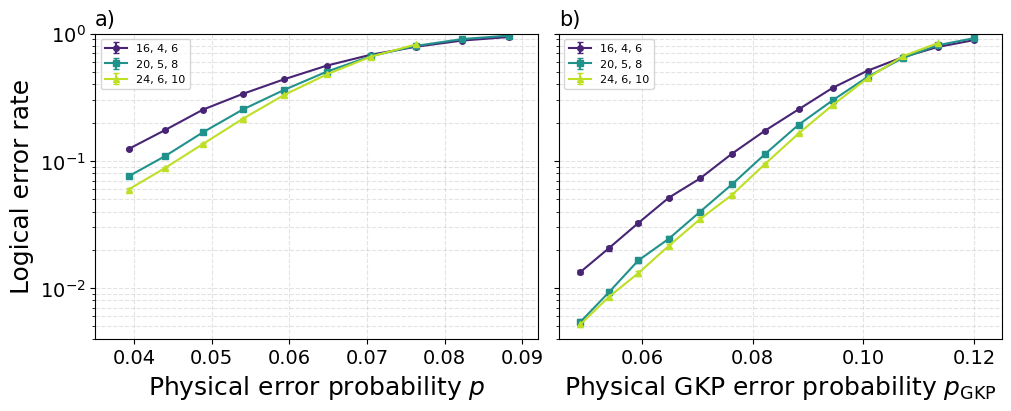

In [111]:
mkmn_seeds = ('16_4_6', '20_5_8', '24_6_10')
mkmn_markers = dict(zip(mkmn_seeds, ('o', 's', '^')))
mkmn_colours = blue_green_colours(mkmn_seeds)
mkmn_files = [
    (seed.replace('_', ', '), seed,
     prefer_existing(f'gkp_qldpc_mkmn_xz_standard_focused_{seed}_results.json',
                     f'gkp_qldpc_mkmn_xz_standard_quick_{seed}_results.json'),
     prefer_existing(f'gkp_qldpc_mkmn_xz_focused_{seed}_results.json',
                     f'gkp_qldpc_mkmn_xz_quick_{seed}_results.json'))
    for seed in mkmn_seeds
]

print_caption('MKMN finite-size comparison. a) Standard decoding. b) Soft-GKP decoding. Marker shape distinguishes the substantially different code parameters: circles (16,4,6), squares (20,5,8), and triangles (24,6,10). These curves show a finite-size turn-on rather than a stable common crossing.')
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, sharey=True)
for label, seed, standard_file, gkp_file in mkmn_files:
    for axis, filename in zip(axes, (standard_file, gkp_file)):
        _, physical, rate, error = load_block_curve(filename)
        visible = (physical > 0) & (rate > 0)
        axis.errorbar(physical[visible], rate[visible], yerr=error[visible],
                      marker=mkmn_markers[seed], ms=4, capsize=2,
                      color=mkmn_colours[seed], label=label)
for axis, panel_label, xlim in zip(axes, ('a)', 'b)'), ((0.035, 0.092), (0.045, 0.125))):
    axis.set_title(panel_label, loc='left')
    axis.set_yscale('log'); axis.set_xlim(*xlim); axis.set_ylim(4e-3, 1.0)
    axis.grid(True, which='both', linestyle='--', alpha=0.35)
    axis.legend(fontsize=8)
axes[0].set_xlabel(r'Physical error probability $p$')
axes[1].set_xlabel(r'Physical GKP error probability $p_{\mathrm{GKP}}$')
axes[0].set_ylabel('Logical error rate')
fig.savefig('mkmn_quick_threshold_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## Bivariate bicycle code with GKP decoding

These fixed-size results compare hard-decision and shot-specific analogue BP--OSD decoding for the $[[72,12,6]]$ bivariate bicycle code. They test decoder performance and the $X/Z$ squeezing trade-off; they do not constitute a threshold estimate.


Figure caption: Bivariate-bicycle $[[72,12,6]]$ block logical error. a) Hard-decision BP--OSD. b) Shot-specific analogue BP--OSD. Viridis colour denotes position squeezing.


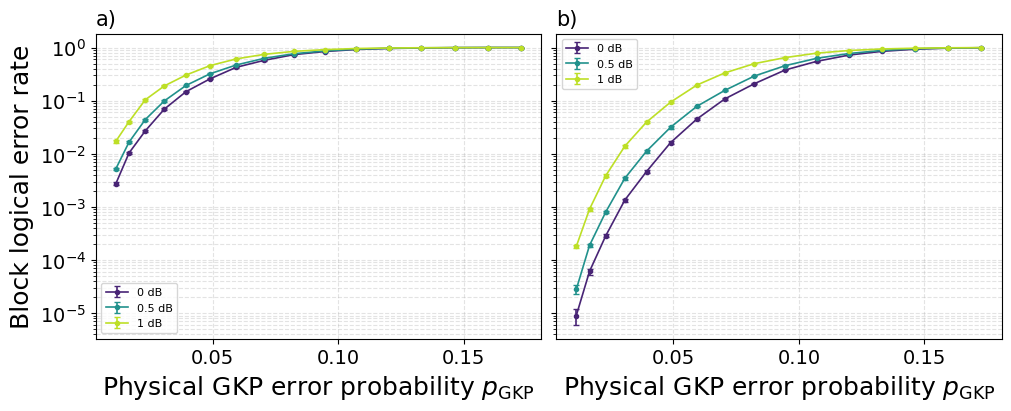

Figure caption: Improvement factor from shot-specific analogue information for the $[[72,12,6]]$ bivariate-bicycle code; values above one favour analogue decoding.


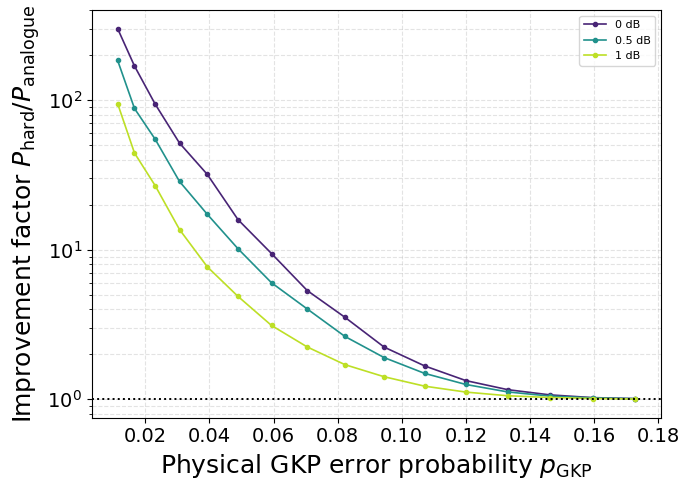

Figure caption: Analogue-decoded $[[72,12,6]]$ bivariate-bicycle sector failure rates versus position squeezing. a) X sector. b) Z sector.


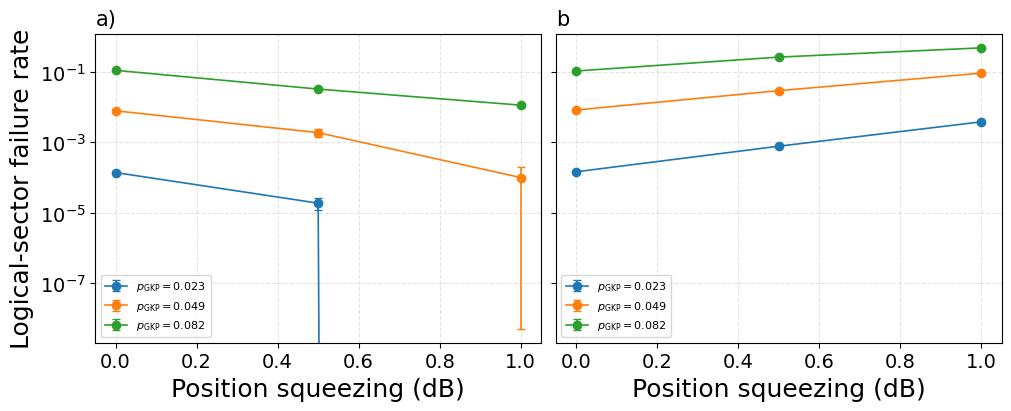

BB72 simulation setup


,Quantity,Value
0,Code,"[[72,12,6]] bivariate bicycle"
1,Check weight,6
2,Decoder,"BP--OSD, order 2"
3,Noise,Independent Gaussian GKP shifts
4,Syndrome measurements,Perfect
5,Squeezing,"0, 0.5, 1 dB"
6,$p_{\mathrm{GKP}}$ range,0.0113--0.1727 (16 points; unsqueezed-equivale...
7,Sampling,"At least 10,000 trials; target 300 block failu..."


BB72 representative block-error results


,$p_{\mathrm{GKP}}$,Squeezing (dB),Physical $p_X$,Physical $p_Z$,Hard block rate,Analogue block rate,Improvement factor
0,1.134e-02,0.0,1.134e-02,1.134e-02,2.720e-03,9.000e-06,302.24
1,1.134e-02,0.5,7.316e-03,1.683e-02,5.184e-03,2.800e-05,185.15
2,1.134e-02,1.0,4.497e-03,2.403e-02,1.713e-02,1.800e-04,95.18
3,4.891e-02,0.0,4.891e-02,4.891e-02,2.578e-01,1.622e-02,15.90
4,4.891e-02,0.5,3.697e-02,6.299e-02,3.208e-01,3.160e-02,10.15
5,4.891e-02,1.0,2.713e-02,7.922e-02,4.570e-01,9.380e-02,4.87
6,1.071e-01,0.0,1.071e-01,1.071e-01,9.182e-01,5.497e-01,1.67
7,1.071e-01,0.5,8.786e-02,1.282e-01,9.327e-01,6.266e-01,1.49
8,1.071e-01,1.0,7.062e-02,1.510e-01,9.581e-01,7.838e-01,1.22


In [112]:
# BB72: hard/analogue block error, analogue gain, X/Z trade-off, and tables
def load_bb72_result(decoder, squeezing):
    squeeze_tag = f'{squeezing:g}'.replace('.', 'p')
    path = Path(f'bb72_gkp_{decoder}_sq{squeeze_tag}dB_results.json')
    with path.open(encoding='utf-8') as file:
        saved = json.load(file)
    points = sorted(
        (point for point in saved['points'].values() if 'block_rate' in point),
        key=lambda point: point['sigma'],
    )
    return saved, points

bb_squeezing = (0.0, 0.5, 1.0)
bb_data = {
    (decoder, squeezing): load_bb72_result(decoder, squeezing)
    for decoder in ('hard', 'analog') for squeezing in bb_squeezing
}
bb_colours = dict(zip(bb_squeezing, BLUE_GREEN_CMAP(np.linspace(0.10, 0.90, len(bb_squeezing)))))

print_caption(r'Bivariate-bicycle $[[72,12,6]]$ block logical error. a) Hard-decision BP--OSD. b) Shot-specific analogue BP--OSD. Viridis colour denotes position squeezing.')
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, sharey=True)
for axis, decoder, panel_label in zip(axes, ('hard', 'analog'), ('a)', 'b)')):
    for squeezing in bb_squeezing:
        _, points = bb_data[(decoder, squeezing)]
        sigma = np.asarray([point['sigma'] for point in points])
        physical = gkp_physical_error_rate(sigma)
        rate = np.asarray([point['block_rate'] for point in points])
        error = np.asarray([point['block_standard_error'] for point in points])
        visible = rate > 0
        axis.errorbar(physical[visible], rate[visible], yerr=error[visible], marker='o',
                      ms=3, capsize=2, linewidth=1.2, color=bb_colours[squeezing],
                      label=fr'{squeezing:g} dB')
    axis.set_title(panel_label, loc='left')
    axis.set_xlabel(r'Physical GKP error probability $p_{\mathrm{GKP}}$')
    axis.set_yscale('log')
    axis.grid(True, which='both', linestyle='--', alpha=0.35)
    axis.legend(fontsize=8)
axes[0].set_ylabel('Block logical error rate')
fig.savefig('diss_bb72_hard_vs_analog.png', dpi=300, bbox_inches='tight')
plt.show()

print_caption(r'Improvement factor from shot-specific analogue information for the $[[72,12,6]]$ bivariate-bicycle code; values above one favour analogue decoding.')
fig, axis = plt.subplots(figsize=(7, 5))
for squeezing in bb_squeezing:
    hard = {point['sigma']: point for point in bb_data[('hard', squeezing)][1]}
    analog = {point['sigma']: point for point in bb_data[('analog', squeezing)][1]}
    common = sorted(set(hard) & set(analog))
    gain = np.asarray([hard[s]['block_rate'] / analog[s]['block_rate']
                       if analog[s]['block_rate'] > 0 else np.nan for s in common])
    physical = gkp_physical_error_rate(common)
    axis.plot(physical, gain, marker='o', ms=3, linewidth=1.2,
              color=bb_colours[squeezing], label=fr'{squeezing:g} dB')
axis.axhline(1, color='black', linestyle=':', linewidth=1.4)
axis.set_xlabel(r'Physical GKP error probability $p_{\mathrm{GKP}}$')
axis.set_ylabel(r'Improvement factor $P_{\rm hard}/P_{\rm analogue}$')
axis.set_yscale('log')
axis.grid(True, which='both', linestyle='--', alpha=0.35)
axis.legend(fontsize=8)
fig.tight_layout()
fig.savefig('diss_bb72_analog_improvement.png', dpi=300, bbox_inches='tight')
plt.show()

print_caption(r'Analogue-decoded $[[72,12,6]]$ bivariate-bicycle sector failure rates versus position squeezing. a) X sector. b) Z sector.')
selected_sigmas = (0.39, 0.45, 0.51)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, sharey=True)
for axis, field, panel_label, sector in zip(axes, ('x_rate', 'z_rate'), ('a)', 'b'), ('X', 'Z')):
    for sigma in selected_sigmas:
        rates, errors = [], []
        for squeezing in bb_squeezing:
            point = min(bb_data[('analog', squeezing)][1], key=lambda item: abs(item['sigma'] - sigma))
            rates.append(point[field])
            errors.append(point[f'{field[0]}_standard_error'])
        axis.errorbar(bb_squeezing, rates, yerr=errors, marker='o', capsize=3,
                      linewidth=1.2, label=fr'$p_{{\mathrm{{GKP}}}}={float(gkp_physical_error_rate(sigma)):.3f}$')
    axis.set_title(panel_label, loc='left')
    axis.set_xlabel('Position squeezing (dB)')
    axis.set_yscale('log')
    axis.grid(True, which='both', linestyle='--', alpha=0.35)
    axis.legend(fontsize=8)
axes[0].set_ylabel('Logical-sector failure rate')
fig.savefig('diss_bb72_xz_squeezing_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()


print('BB72 simulation setup')
bb_setup_table = pd.DataFrame([
    ('Code', '[[72,12,6]] bivariate bicycle'),
    ('Check weight', '6'),
    ('Decoder', 'BP--OSD, order 2'),
    ('Noise', 'Independent Gaussian GKP shifts'),
    ('Syndrome measurements', 'Perfect'),
    ('Squeezing', '0, 0.5, 1 dB'),
    (r'$p_{\mathrm{GKP}}$ range', '0.0113--0.1727 (16 points; unsqueezed-equivalent coordinate)'),
    ('Sampling', 'At least 10,000 trials; target 300 block failures; maximum 1,000,000'),
], columns=('Quantity', 'Value'))
display(bb_setup_table)

print('BB72 representative block-error results')
representative_sigmas = (0.35, 0.45, 0.55)
rows = []
for sigma in representative_sigmas:
    for squeezing in bb_squeezing:
        hard_point = min(bb_data[('hard', squeezing)][1], key=lambda item: abs(item['sigma'] - sigma))
        analog_point = min(bb_data[('analog', squeezing)][1], key=lambda item: abs(item['sigma'] - sigma))
        rows.append({
            r'$p_{\mathrm{GKP}}$': float(gkp_physical_error_rate(sigma)),
            'Squeezing (dB)': squeezing,
            r'Physical $p_X$': analog_point['physical_p_x'],
            r'Physical $p_Z$': analog_point['physical_p_z'],
            'Hard block rate': hard_point['block_rate'],
            'Analogue block rate': analog_point['block_rate'],
            'Improvement factor': hard_point['block_rate'] / analog_point['block_rate']
                                  if analog_point['block_rate'] > 0 else np.nan,
        })
bb_results_table = pd.DataFrame(rows)
bb_results_display = bb_results_table.copy()
for column in (r'$p_{\mathrm{GKP}}$', r'Physical $p_X$', r'Physical $p_Z$',
               'Hard block rate', 'Analogue block rate'):
    bb_results_display[column] = bb_results_display[column].map('{:.3e}'.format)
bb_results_display['Improvement factor'] = bb_results_display['Improvement factor'].map('{:.2f}'.format)
display(bb_results_display)


## Asymmetric codes

Squeezed-GKP bias is shown last, first for the fixed-aspect asymmetric HGP family and pilot code, then as a threshold-versus-squeezing summary.


Figure caption: Asymmetric HGP--GKP threshold scaling for position squeezing of a) 0 dB, b) 1 dB, c) 2 dB, and d) 3 dB. Curves correspond to increasing asymmetric distances with fixed ratio $d_Z/d_X=5/3$.


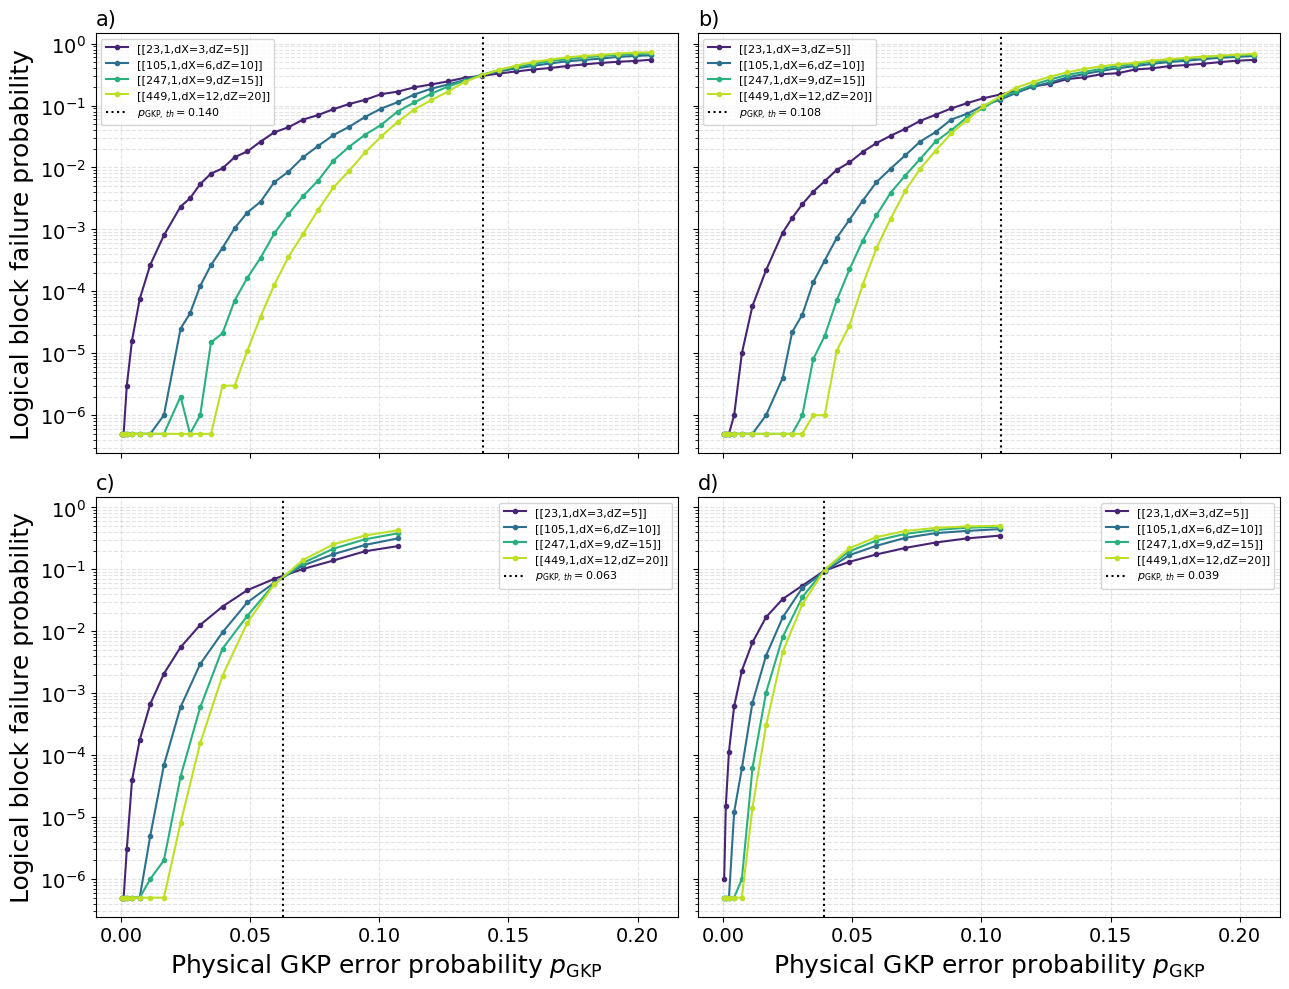

In [113]:
# Fixed-aspect asymmetric HGP family: distance scaling and crossing evidence
hgp_family = []
for filename in glob.glob('asymmetric_hgp_qX_pZ_v2_*_sq*dB_results.json'):
    with open(filename, encoding='utf-8') as file:
        dataset = json.load(file)
    assert dataset['quadrature_pauli_convention'] == 'q displacement -> X; p displacement -> Z'
    if dataset['family'] == 'HGP of unequal repetition codes':
        hgp_family.append(dataset)

distance_order = {'[[23,1,dX=3,dZ=5]]': 3, '[[105,1,dX=6,dZ=10]]': 6,
                  '[[247,1,dX=9,dZ=15]]': 9, '[[449,1,dX=12,dZ=20]]': 12}

def adjacent_hgp_crossings(selected, minimum_rate=1e-3):
    # Interpolate where log(p_large/p_small) changes from negative to positive.
    curves = {}
    for dataset in selected:
        dx = distance_order[dataset['code']]
        curves[dx] = {round(p['sigma'], 8): max(p['block_rate'], 0.5/p['trials'])
                      for p in dataset['points'].values() if 'block_rate' in p}
    crossings = []
    for smaller, larger in ((3, 6), (6, 9), (9, 12)):
        previous = None
        for sigma in sorted(set(curves[smaller]) & set(curves[larger])):
            p_small, p_large = curves[smaller][sigma], curves[larger][sigma]
            if max(p_small, p_large) < minimum_rate:
                continue
            difference = np.log(p_large) - np.log(p_small)
            if previous is not None and previous[1] < 0 <= difference:
                sigma0, difference0 = previous
                crossing = sigma0 + (sigma-sigma0)*(-difference0)/(difference-difference0)
                crossings.append(crossing)
                break
            previous = (sigma, difference)
    return crossings

print_caption(r'Asymmetric HGP--GKP threshold scaling for position squeezing of a) 0 dB, b) 1 dB, c) 2 dB, and d) 3 dB. Curves correspond to increasing asymmetric distances with fixed ratio $d_Z/d_X=5/3$.')
hgp_threshold_summary = {}
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
for panel_index, (axis, squeezing) in enumerate(zip(axes.flat, (0, 1, 2, 3))):
    selected = sorted((d for d in hgp_family if float(d['squeezing_db']) == squeezing),
                      key=lambda d: distance_order[d['code']])
    crossings = adjacent_hgp_crossings(selected)
    threshold = float(np.mean(crossings))
    spread = float(np.std(crossings, ddof=1))
    physical_crossings = np.asarray(gkp_physical_error_rate(crossings), dtype=float)
    physical_threshold = float(gkp_physical_error_rate(threshold))
    physical_spread = float(np.std(physical_crossings, ddof=1))
    hgp_threshold_summary[squeezing] = {
        'threshold': threshold, 'spread': spread, 'pair_crossings': crossings,
        'physical_threshold': physical_threshold, 'physical_spread': physical_spread,
        'physical_pair_crossings': physical_crossings.tolist(),
    }
    for dataset in selected:
        points = sorted((p for p in dataset['points'].values() if 'block_rate' in p), key=lambda p: p['sigma'])
        rates = [max(p['block_rate'], 0.5 / p['trials']) for p in points]
        physical = gkp_physical_error_rate([p['sigma'] for p in points])
        axis.plot(physical, rates, 'o-', ms=3, color=BLUE_GREEN_CMAP(0.10 + 0.80 * (distance_order[dataset['code']] - 3) / 9), label=dataset['code'])
    axis.axvline(physical_threshold, color='black', linestyle=':', linewidth=1.5,
                 label=fr'$p_{{\mathrm{{GKP}},\,th}}={physical_threshold:.3f}$')
    axis.set_yscale('log'); axis.set_title(f"{'abcd'[panel_index]})", loc='left')
    axis.grid(True, which='both', linestyle='--', alpha=0.35); axis.legend(fontsize=8)
for axis in axes[-1]: axis.set_xlabel(r'Physical GKP error probability $p_{\mathrm{GKP}}$')
for axis in axes[:, 0]: axis.set_ylabel('Logical block failure probability')
fig.tight_layout(); fig.savefig('diss_asymmetric_hgp_thresholds.png', dpi=300, bbox_inches='tight'); plt.show()


Figure caption: Asymmetric HGP--GKP pilot $[[47,4,d_X=3,d_Z=5]]$: logical block failure versus physical GKP error probability for several squeezing values.
Figure caption: Asymmetric HGP--GKP pilot $[[47,4,d_X=3,d_Z=5]]$: X/Z logical-sector trade-off under position squeezing.


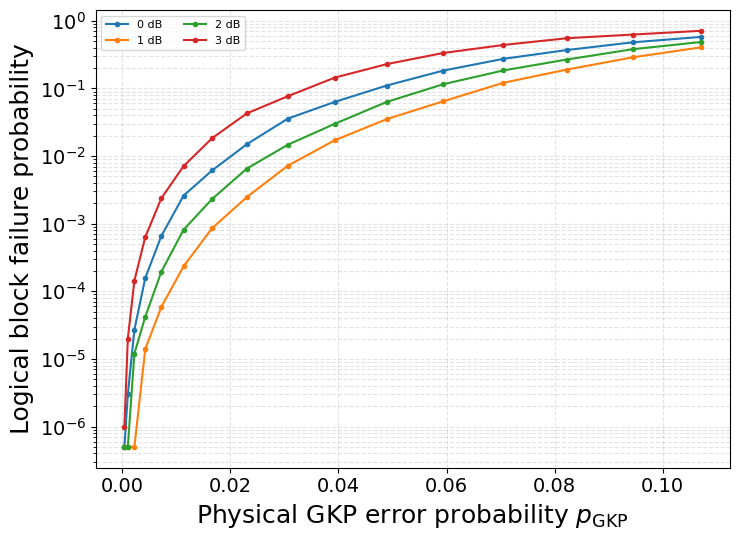

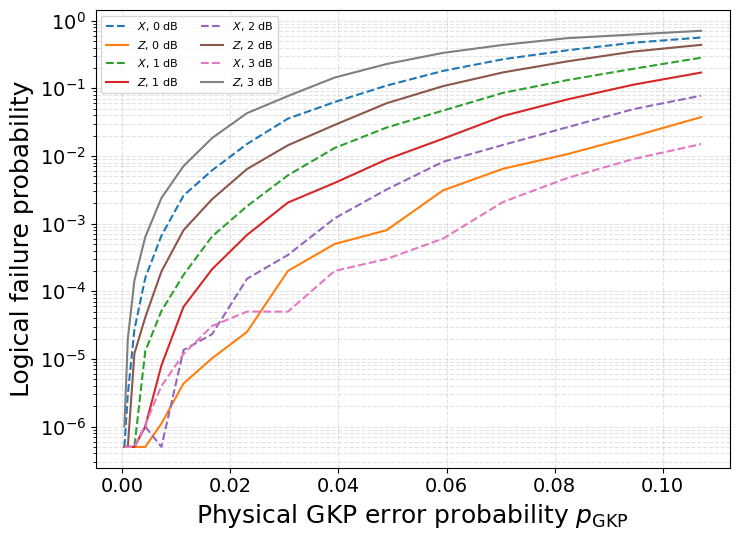

In [114]:
print_caption(r'Asymmetric HGP--GKP pilot $[[47,4,d_X=3,d_Z=5]]$: logical block failure versus physical GKP error probability for several squeezing values.')
# Small non-surface pilot: HGP(rep[5,1,5], Hamming[7,4,3]) = [[47,4,3,5]]
pilot = []
for filename in glob.glob('asymmetric_hgp_qX_pZ_v2_rep5xhamming7_sq*dB_results.json'):
    with open(filename, encoding='utf-8') as file:
        pilot.append(json.load(file))
fig_block, axis_block = plt.subplots(figsize=(7.5, 5.5))
fig_xz, axis_xz = plt.subplots(figsize=(7.5, 5.5))
for dataset in sorted(pilot, key=lambda d: d['squeezing_db']):
    points = sorted((p for p in dataset['points'].values() if 'block_rate' in p), key=lambda p: p['sigma'])
    squeezing = dataset['squeezing_db']
    physical = gkp_physical_error_rate([p['sigma'] for p in points])
    axis_block.plot(physical,
                 [max(p['block_rate'], 0.5/p['trials']) for p in points],
                 'o-', ms=3, label=f'{squeezing:g} dB')
    axis_xz.plot(physical,
                 [max(p['x_rate'], 0.5/p['trials']) for p in points],
                 '--', label=fr'$X$, {squeezing:g} dB')
    axis_xz.plot(physical,
                 [max(p['z_rate'], 0.5/p['trials']) for p in points],
                 '-', label=fr'$Z$, {squeezing:g} dB')
for axis in (axis_block, axis_xz):
    axis.set_yscale('log'); axis.set_xlabel(r'Physical GKP error probability $p_{\mathrm{GKP}}$')
    axis.grid(True, which='both', linestyle='--', alpha=0.35); axis.legend(fontsize=8, ncol=2)
axis_block.set_ylabel('Logical block failure probability')
fig_block.tight_layout()
fig_block.savefig('diss_asymmetric_hgp_pilot_block_failure.png', dpi=300, bbox_inches='tight')
axis_xz.set_ylabel('Logical failure probability')
print_caption(r'Asymmetric HGP--GKP pilot $[[47,4,d_X=3,d_Z=5]]$: X/Z logical-sector trade-off under position squeezing.')
fig_xz.tight_layout()
fig_xz.savefig('diss_asymmetric_hgp_pilot_xz_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()


### Asymmetric-HGP threshold versus squeezing

Each estimate is the mean of the three adjacent-size crossings. The quoted spread measures finite-size drift rather than a full statistical confidence interval.


,Position squeezing (dB),Estimated physical threshold,Adjacent-pair spread,Pair crossings,Change from 0 dB (%)
0,0,0.1403,0.0033,"0.1377, 0.1392, 0.1439",+0.0%
1,1,0.1077,0.0117,"0.1209, 0.1042, 0.0983",-23.2%
2,2,0.0628,0.0023,"0.0650, 0.0630, 0.0605",-55.2%
3,3,0.0392,0.0013,"0.0404, 0.0378, 0.0395",-72.0%


Figure caption: Estimated asymmetric HGP--GKP threshold versus position squeezing. Error bars show the spread among adjacent-size crossings; the dotted line is the unsqueezed reference.


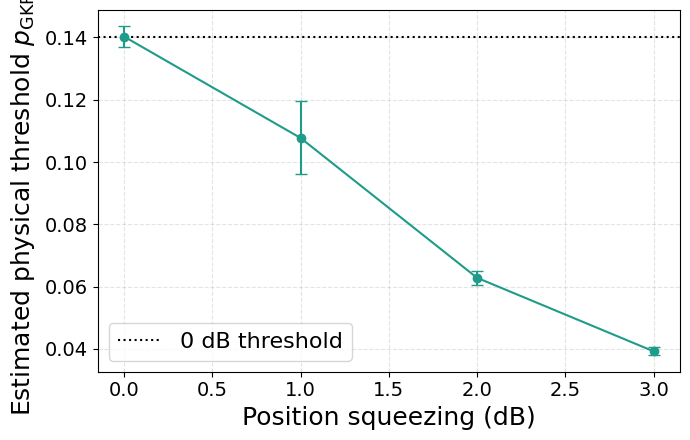

In [115]:
# Threshold-versus-squeezing table, calculated from the guide lines above
baseline_hgp_threshold = hgp_threshold_summary[0]['physical_threshold']
hgp_squeezing_threshold_table = pd.DataFrame([
    {
        'Position squeezing (dB)': squeezing,
        'Estimated physical threshold': values['physical_threshold'],
        'Adjacent-pair spread': values['physical_spread'],
        'Pair crossings': ', '.join(f'{value:.4f}' for value in values['physical_pair_crossings']),
        'Change from 0 dB (%)': 100*(values['physical_threshold']/baseline_hgp_threshold - 1),
    }
    for squeezing, values in sorted(hgp_threshold_summary.items())
])
hgp_squeezing_threshold_display = hgp_squeezing_threshold_table.copy()
hgp_squeezing_threshold_display['Estimated physical threshold'] = hgp_squeezing_threshold_display['Estimated physical threshold'].map('{:.4f}'.format)
hgp_squeezing_threshold_display['Adjacent-pair spread'] = hgp_squeezing_threshold_display['Adjacent-pair spread'].map('{:.4f}'.format)
hgp_squeezing_threshold_display['Change from 0 dB (%)'] = hgp_squeezing_threshold_display['Change from 0 dB (%)'].map('{:+.1f}%'.format)
display(hgp_squeezing_threshold_display)

print_caption('Estimated asymmetric HGP--GKP threshold versus position squeezing. Error bars show the spread among adjacent-size crossings; the dotted line is the unsqueezed reference.')
fig, axis = plt.subplots(figsize=(7, 4.5))
axis.errorbar(hgp_squeezing_threshold_table['Position squeezing (dB)'],
              hgp_squeezing_threshold_table['Estimated physical threshold'],
              yerr=hgp_squeezing_threshold_table['Adjacent-pair spread'],
              fmt='o-', capsize=4, color=BLUE_GREEN_CMAP(0.55))
axis.axhline(baseline_hgp_threshold, color='black', linestyle=':', label='0 dB threshold')
axis.set_xlabel('Position squeezing (dB)'); axis.set_ylabel(r'Estimated physical threshold $p_{\mathrm{GKP},th}$')
axis.grid(True, linestyle='--', alpha=0.35); axis.legend()
fig.tight_layout(); fig.savefig('diss_asymmetric_hgp_threshold_vs_squeezing.png', dpi=300, bbox_inches='tight'); plt.show()
